# LensLab · Do known candidates have more candidate neighbours?

**One question:** in an image representation, are the ten neighbours of a known lens candidate more often other catalogued candidates than the neighbours of a comparable unlabelled object?

We use **1,126 pairs**. Each candidate has one reference with similar apparent brightness and area, in the same sky neighbourhood. These catalogue properties define the pair; **Zoobot similarity is measured afterwards**, without training on the candidate labels. Reference objects are outside the published candidate list, not confirmed non-lenses.

The exact S1/S2 simulations and curated inspected negatives needed to reproduce the supervised lens model of Paper C were not recovered for this project. This notebook instead studies the structure of a frozen image representation.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from lenslab import neighbours, second_encoder, neighbour_gallery

## 1. Find image neighbours, then reveal their labels

We reuse the authors' **40 published PCA coordinates** for every object, joined by exact object ID. They were computed from 512 Zoobot morphology features upstream. We do not rerun that encoder, refit PCA, standardize the coordinates or use a lens-specialized fine-tuned checkpoint.

For each object, search the full 40-dimensional space using Euclidean distance. Exclude **the object itself and its partner**, then retain ten nearest neighbours. Count how many are catalogued candidates. The primary result compares the candidate anchor's share with its paired reference's share, averaged across all pairs.

The corpus is deliberately 50% candidates by construction. It does not estimate the prevalence of lenses in Euclid.

In [2]:
summary = neighbours.run(ROOT)
primary = summary["primary"]
display(pd.DataFrame([{
    "Objects": summary["objects"], "Matched pairs": summary["matched_pairs"],
    "Zoobot coordinates": summary["dimensions"],
    "Around candidates (%)": 100 * primary["candidate_neighbour_fraction"],
    "Around references (%)": 100 * primary["reference_neighbour_fraction"],
    "Difference (percentage points)": 100 * primary["difference"],
}]).round(2))

2,252 objects / 1,126 pairs: 81.4% vs 25.3% candidate neighbours.


,Objects,Matched pairs,Zoobot coordinates,Around candidates (%),Around references (%),Difference (percentage points)
0,2252,1126,40,81.41,25.3,56.11


### Inspect the actual neighbours

Three pairs are drawn with a fixed seed, one per candidate grade, before reading
neighbour counts or image availability. Both members serve as anchors. Show all
ten neighbours from the full 2,252-object graph, in rank order; unavailable images
remain placeholders. This is an illustration, not another performance estimate.

These are VIS previews of 9.6 arcseconds, with a 2-arcsecond scale bar. Zoobot
distances come from the authors’ VIS+Y representations, not these local previews.
The HTML version lets you switch pairs, reveal labels and enlarge the images.

Gallery VIS previews: 65 cached; 0 to acquire.
Gallery: 3 fixed pairs, 66 unique objects, 65 VIS previews.
  Grade A: candidate 9/10; reference 2/10
  Grade B: candidate 10/10; reference 1/10
  Grade C: candidate 9/10; reference 6/10


,Pair,Candidate grade,Candidates near candidate / 10,Candidates near reference / 10
0,1,A,9,2
1,2,B,10,1
2,3,C,9,6


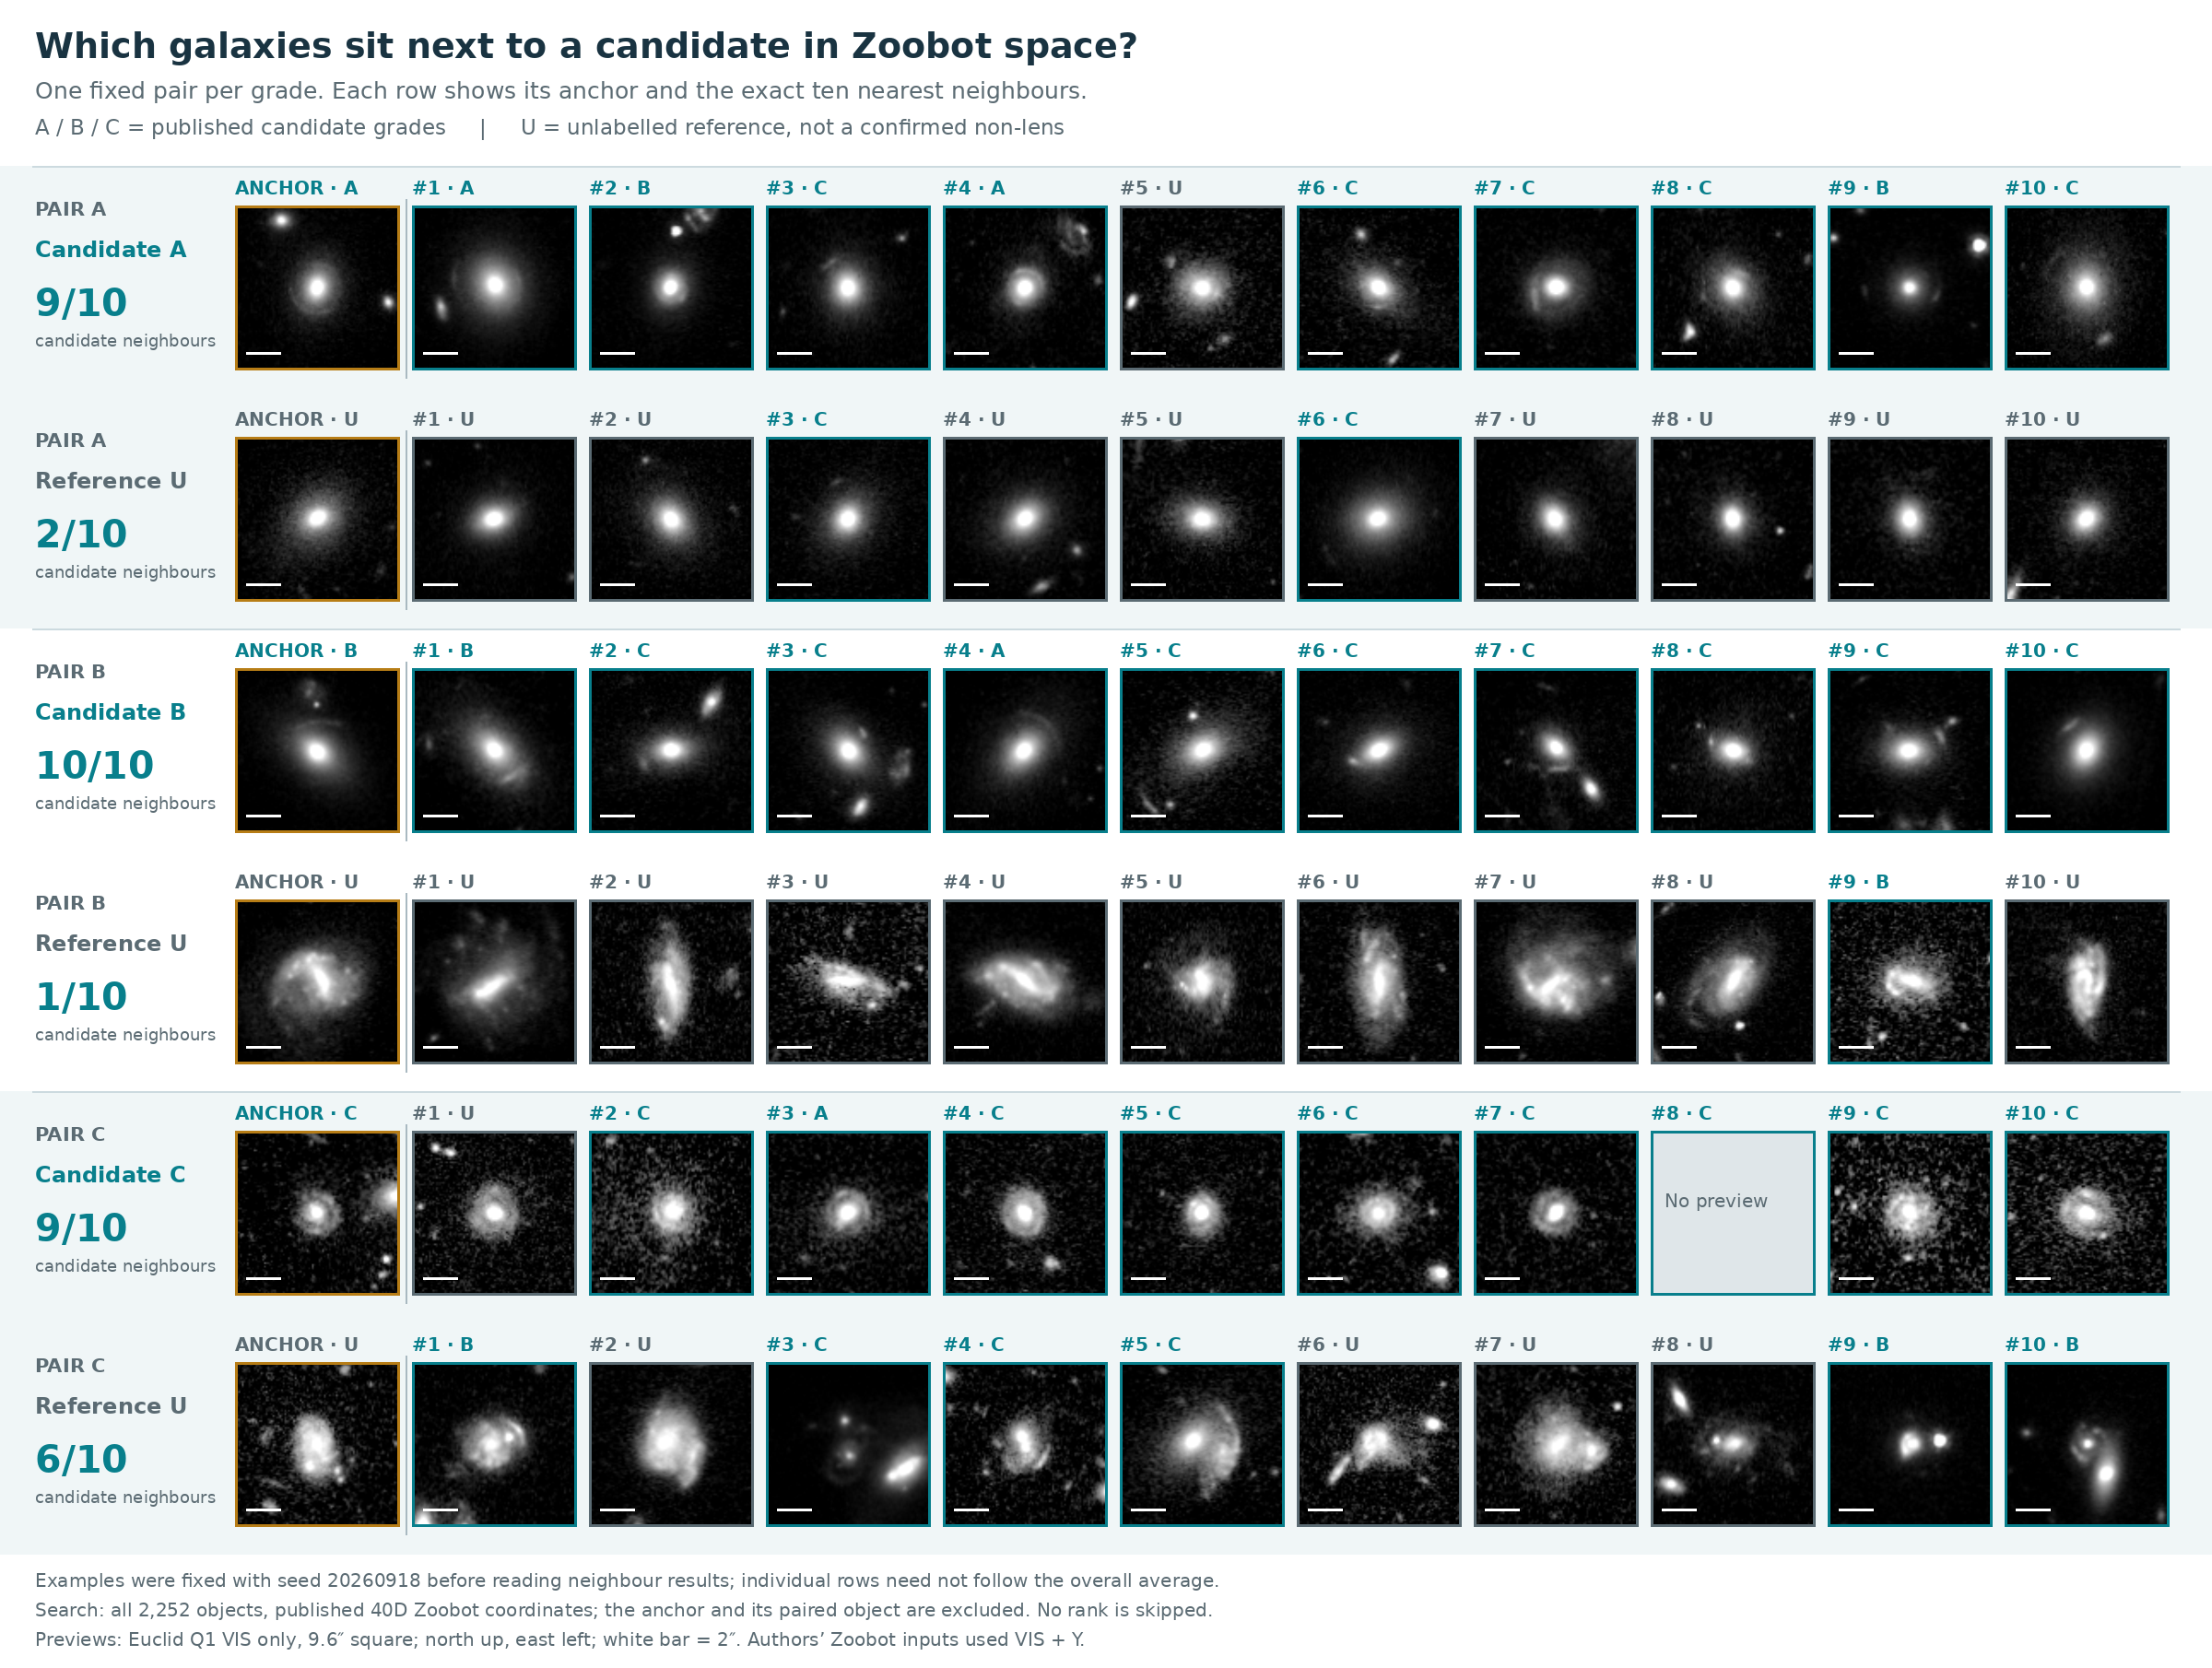

In [3]:
gallery = neighbour_gallery.run(ROOT)
display(pd.DataFrame([{
    "Pair": i + 1, "Candidate grade": pair["grade"],
    "Candidates near candidate / 10": pair["candidate_labelled_count"],
    "Candidates near reference / 10": pair["reference_labelled_count"],
} for i, pair in enumerate(gallery["pairs"])]))
display(Image(filename=str(ROOT / "figures/neighbour_gallery.png")))

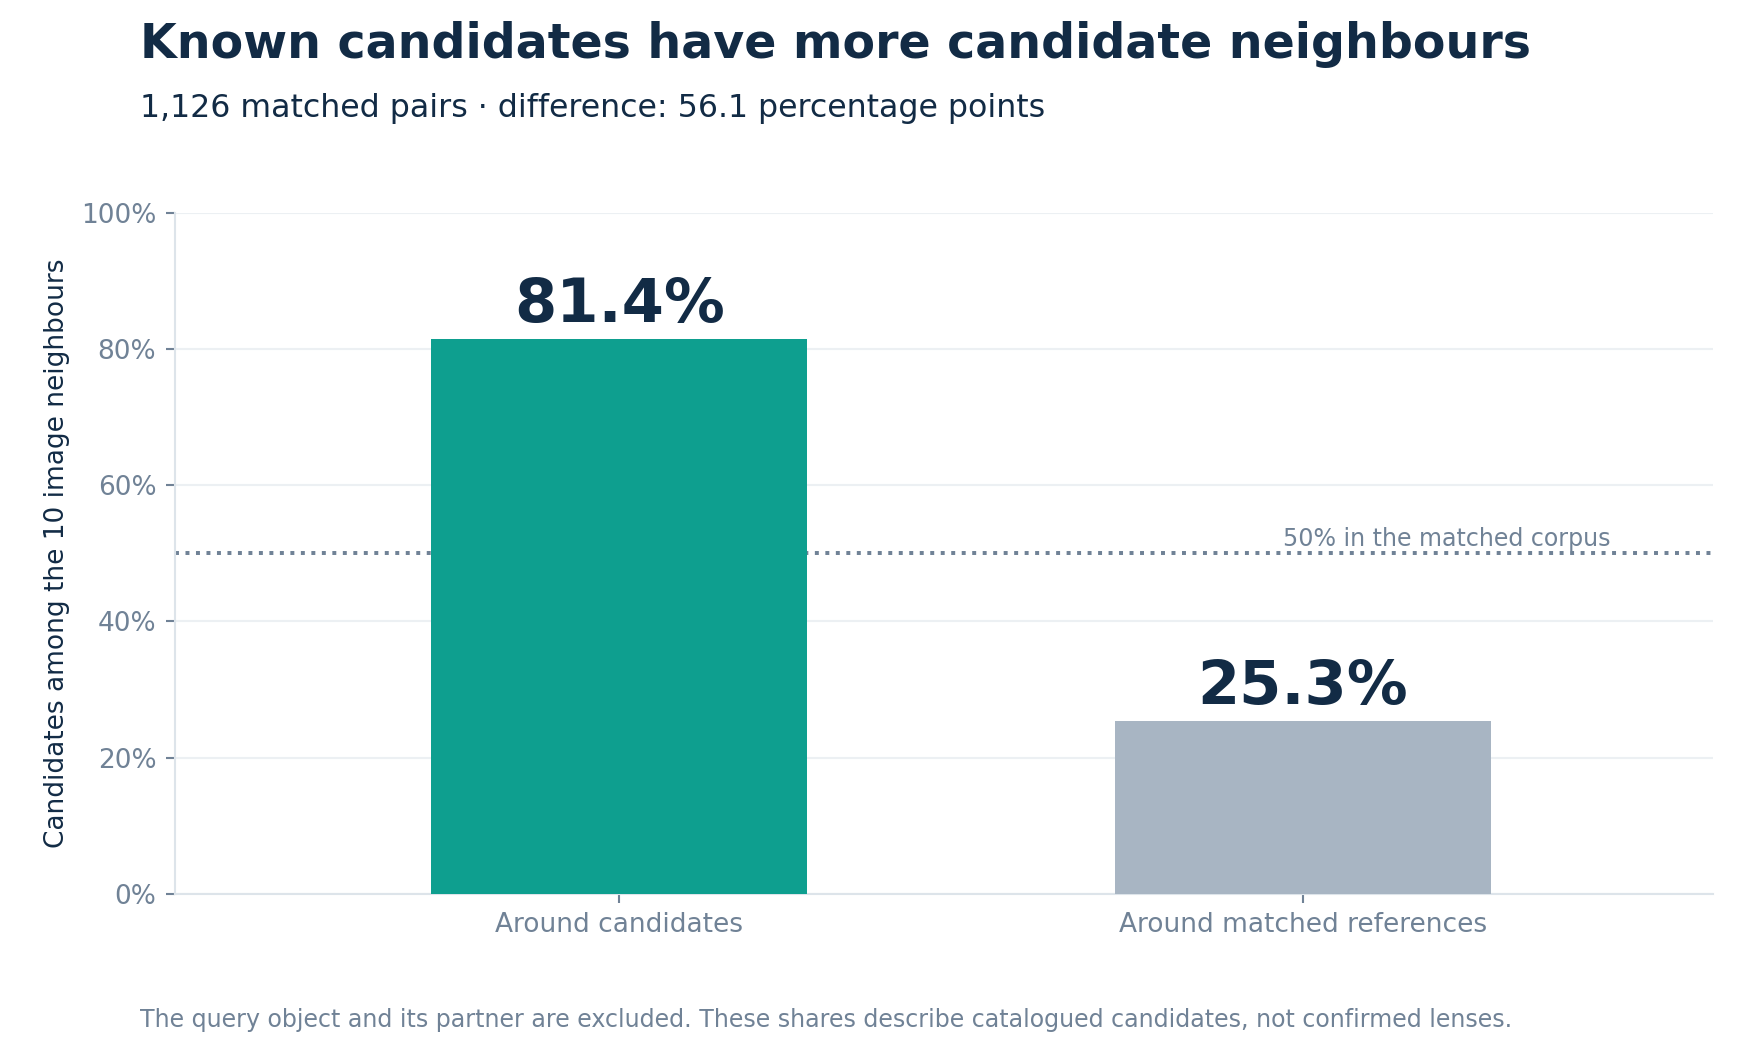

In [4]:
display(Image(filename=str(ROOT / "figures/neighbours.png")))

**Result:** candidate anchors have about 81.4% catalogued candidates among their neighbours, compared with 25.3% around matched references: a **56.1-point contrast**.

This shows that the existing candidate selection is concentrated in Zoobot neighbourhoods, even after approximate matching on brightness, area and local sky region. It does **not** demonstrate that the unlabelled neighbours are new lenses.

### Optional statistical detail

Keep the neighbour graph and pairs fixed. Swap candidate/reference identities at random within each pair, 1,000 times; for every permutation, recompute both neighbour labels and which member acts as the candidate anchor. This gives a conditional reference distribution for the same contrast.

The reference assumes labels could be exchanged within pairs. Approximate observational matching does not guarantee that assumption and does not remove dependencies between different pairs. The result is not discovery significance or a detection score.

Conditional two-sided permutation p: 0.000999
The +1 Monte Carlo correction is used; a value of 1/1001 is the resolution of this run.


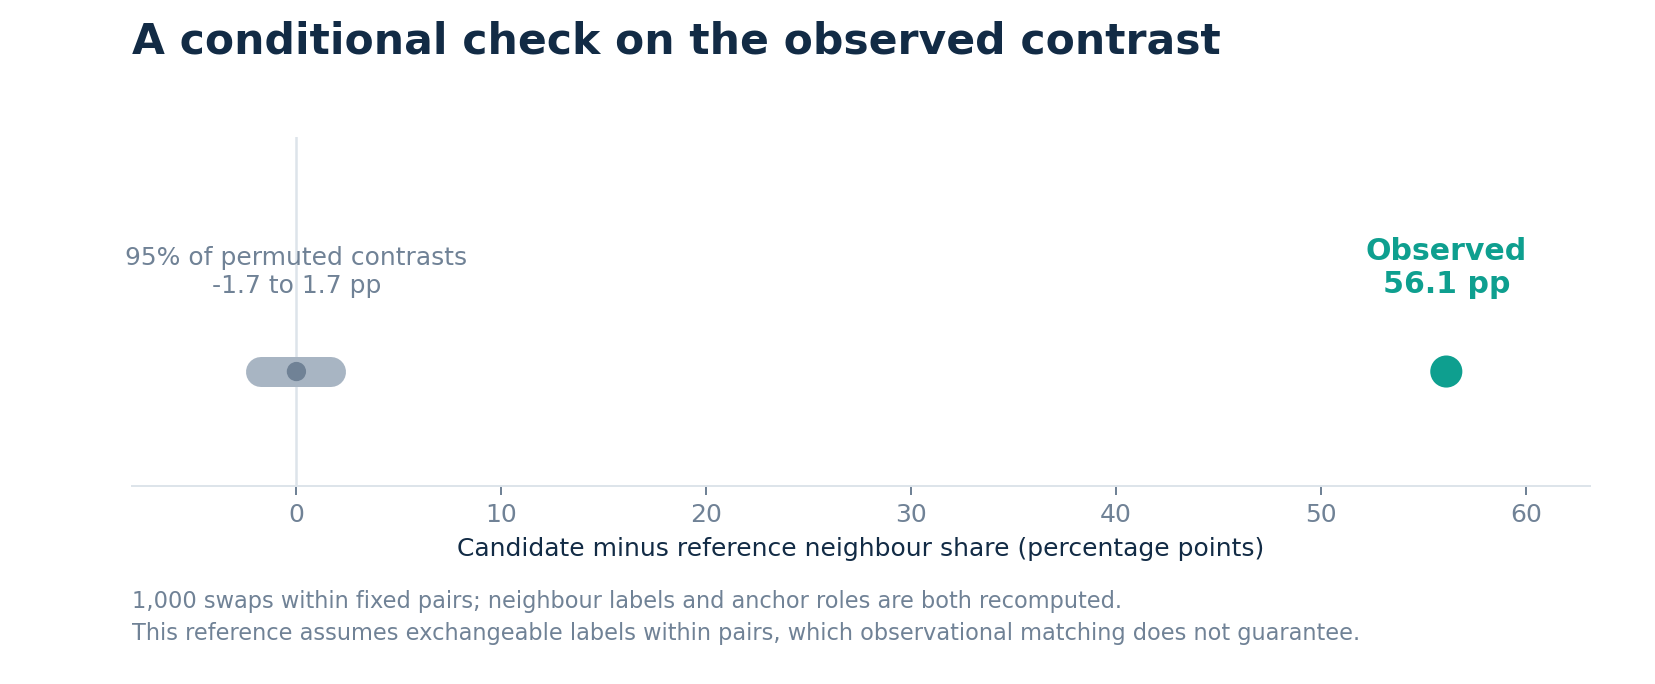

In [5]:
display(Image(filename=str(ROOT / "figures/neighbours_permutation.png")))
print(f"Conditional two-sided permutation p: {primary['permutation_p_two_sided']:.6f}")
print("The +1 Monte Carlo correction is used; a value of 1/1001 is the resolution of this run.")

## 2. Compare Zoobot with a general image encoder

Select **20 pairs per candidate grade A/B/C**, using fixed seed 20260915, before looking at the new images or DINOv2 outputs. Retain these exact IDs. Missing or invalid images remove a whole pair; no replacement is drawn. In the saved acquisition, one unavailable reference image leaves **59 complete pairs / 118 objects**.

The subset has a different grade mixture from the main corpus. Compare the two representations **on this same subset**, not their percentages against the main result.

In [6]:
selected = second_encoder.select_subset(ROOT)
if not (ROOT / "data/processed/second_stamps.npz").exists():
    second_encoder.acquire_images(ROOT)
display(pd.DataFrame([{
    "Selected pairs": selected.set_id.nunique(), "Selected objects": len(selected),
    "Selection seed": second_encoder.SUBSET_SEED,
}]))

,Selected pairs,Selected objects,Selection seed
0,60,120,20260915


**DINOv2 ViT-S/14** is a frozen Transformer pretrained with self-supervision on general images. It returns a 384-number CLS representation; we L2-normalize that vector. No lens labels are supplied and no fine-tuning occurs.

The input is our 96 × 96 VIS stamp, with deterministic background subtraction and asinh stretch. The grey image is repeated across RGB channels, then the official processor resizes and centre-crops it to 224 × 224. The effective crop is 8.4 arcseconds. Published Zoobot uses different VIS+Y inputs and upstream processing.

The cell reuses saved vectors only after checking input/output hashes, object identities, normalization and their matching published Zoobot rows. Set `reuse_cache=False` to re-extract the same frozen features; the device is selected automatically.

In [7]:
provenance = second_encoder.run(ROOT, device="auto", reuse_cache=True)
display(pd.DataFrame([{
    "Complete objects": provenance["complete_objects"],
    "Complete pairs": provenance["complete_sets"],
    "DINOv2 dimensions": 384, "Parameters": provenance["parameters"],
    "Recorded inference device": provenance["execution"]["device"],
    "Recorded inference seconds": round(provenance["execution"]["inference_seconds"], 1),
}]))
print("Excluded image:", provenance["unavailable_image_reasons"])

Verified cached DINOv2 features for 118 objects; original cpu inference: 12.6s.
Excluded image: {'-586591064470200400': 'unavailable: ValueError: incomplete 9.6arcsec stamp: finite fraction 0.000000'}


,Complete objects,Complete pairs,DINOv2 dimensions,Parameters,Recorded inference device,Recorded inference seconds
0,118,59,384,22056576,cpu,12.6


## 3. Recompute the same comparison in both spaces

Find ten neighbours independently in Zoobot 40D and DINOv2 384D, on the **same 118 objects**, again excluding each query and its partner. The same audit code is used for both. Coordinates from the two encoders are never combined.

,Representation,Around candidates (%),Around references (%),Difference (percentage points)
0,Zoobot,80.0,38.5,41.5
1,DINOv2,64.6,53.2,11.4


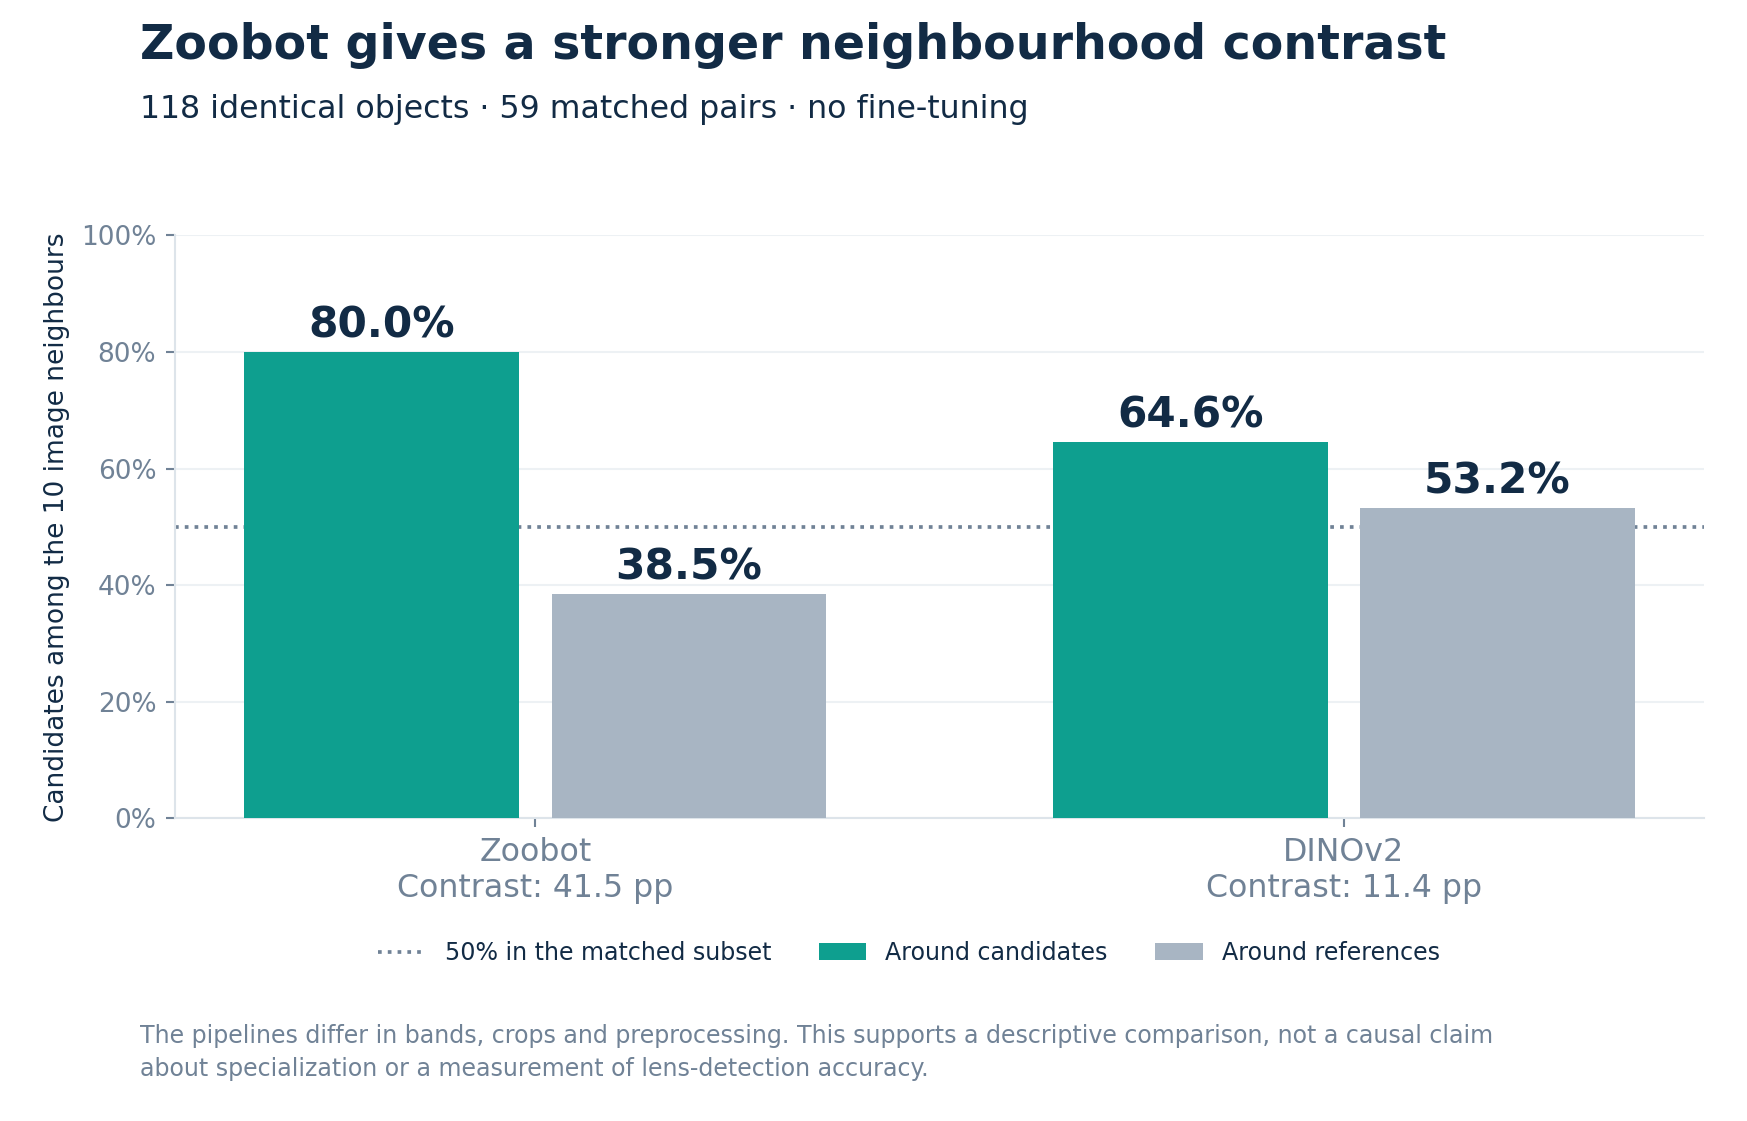

In [8]:
comparison = second_encoder.compare(ROOT)
rows = []
for key, label in [("zoobot", "Zoobot"), ("dino", "DINOv2")]:
    result = comparison[key]
    rows.append({"Representation": label,
                 "Around candidates (%)": 100 * result["candidate_neighbour_fraction"],
                 "Around references (%)": 100 * result["reference_neighbour_fraction"],
                 "Difference (percentage points)": 100 * result["difference"]})
display(pd.DataFrame(rows).round(1))
display(Image(filename=str(ROOT / "figures/second_comparison.png")))

**Conclusion:** on this fixed subset, Zoobot gives a **41.5-point** candidate/reference neighbourhood contrast, compared with **11.4 points** for DINOv2. The Zoobot pipeline is therefore more aligned with the existing candidate labels for this particular task. This is consistent with the potential value of pretraining on galaxy morphology.

It does not isolate the cause: the bands, crop, preprocessing, feature dimensionality and distance normalization also differ. Moreover, the catalogue was partly selected using related image models, so this is not independent validation of Zoobot or a general specialist-versus-generalist benchmark.

## What the analysis establishes — and what remains open

- **Established:** an association between known candidate status and image neighbourhoods in this selected, matched corpus, with a stronger contrast from the published Zoobot pipeline than from our DINOv2 pipeline on the shared subset.
- **Not established:** lens-detection accuracy, new confirmed candidates, the fraction of lenses among unlabelled objects, or generalization to unseen lens morphologies.
- **Next useful validation:** inspect unlabelled neighbours independently with experts and compare encoders using more closely aligned inputs.

Sources: [Published Zoobot representations](https://zenodo.org/records/15106473) · [Morphology paper](https://arxiv.org/abs/2503.15310) · [Lens transfer-learning paper C](https://arxiv.org/abs/2503.15326) · [DINOv2](https://arxiv.org/abs/2304.07193) · [Pinned checkpoint](https://huggingface.co/facebook/dinov2-small/tree/ed25f3a31f01632728cabb09d1542f84ab7b0056).